## Análise exploratória dados fitbit

In [225]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [226]:
# facilitando acesso às pastas para ambas pessoas analisando os dados
caminho_arquivo = Path('dailyActivity_merged.csv').resolve().parents[1]
print('caminho do diretório',caminho_arquivo)

caminho do diretório D:\python\bellabeat-analysis


In [227]:
d_activity = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/dailyActivity_merged.csv')
heartrate = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/heartrate_seconds_merged.csv')
h_calories = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/hourlyCalories_merged.csv')
h_intensity = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/hourlyIntensities_merged.csv')
m_calories = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/minuteCaloriesNarrow_merged.csv')
m_intensity = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/minuteIntensitiesNarrow_merged.csv')
m_sleep = pd.read_csv(f'{caminho_arquivo}//database/fitbit-data/minuteSleep_merged.csv')
weightlog = pd.read_csv(f'{caminho_arquivo}/database/fitbit-data/weightLogInfo_merged_treated.csv')

### Análise de uso das features

####  Gráfico de uso por feature

In [228]:
id_d_activity = d_activity['Id'].nunique()
id_h_calories = h_calories['Id'].nunique()
id_h_intensity = h_intensity['Id'].nunique()
id_m_calories = m_calories['Id'].nunique()
id_m_intensity = m_intensity['Id'].nunique()
id_m_sleep = m_sleep['Id'].nunique()
id_heartrate = heartrate['Id'].nunique()
id_weightlog = weightlog['Id'].nunique()

In [229]:
ids = pd.Series({'Daily activity': id_d_activity, 'Calories': id_h_calories, 'Exercise intensity': id_h_intensity , 'Sleep':id_m_sleep ,  'Heartrate': id_heartrate, 'Weightlog': id_weightlog })
ids

Daily activity        35
Calories              34
Exercise intensity    34
Sleep                 23
Heartrate             14
Weightlog             35
dtype: int64

In [230]:
df_ids = ids.reset_index()
df_ids.columns = ['features', 'count']
df_ids

,features,count
0,Daily activity,35
1,Calories,34
2,Exercise intensity,34
3,Sleep,23
4,Heartrate,14
5,Weightlog,35


In [231]:
sns.set_style('dark')
custom_palette=["#2e0e31", "#5D2F61", "#754B79" ,"#97709B", "#B397B6"]
sns.set_palette(custom_palette)

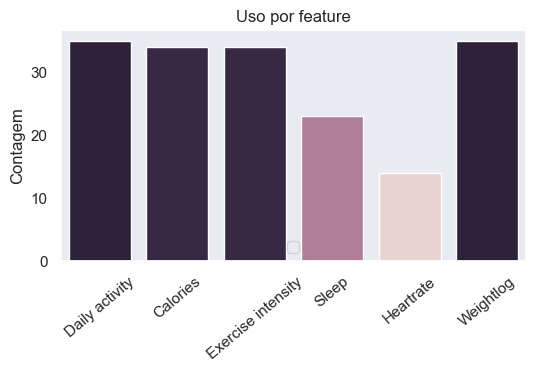

In [232]:
plt.figure(figsize=(6,3))
sns.barplot(data= df_ids, x= 'features', y='count', hue='count')
plt.title('Uso por feature')
plt.xlabel('')
plt.legend('')
plt.xticks(rotation=40)
plt.ylabel('Contagem')
plt.grid(False)
plt.show()

### análise de tipo de exercício (tempo)

In [233]:
fairly_active_minutes_per_id = d_activity.groupby('Id')['FairlyActiveMinutes'].aggregate('sum')
very_active_minutes_per_id = d_activity.groupby('Id')['VeryActiveMinutes'].aggregate('sum')
lightly_active_minutes_per_id = d_activity.groupby('Id')['LightlyActiveMinutes'].aggregate('sum')

fairly_active_minutes_sum = fairly_active_minutes_per_id.sum()
very_active_minutes_sum = very_active_minutes_per_id.sum()
lightly_active_minutes_sum = lightly_active_minutes_per_id.sum()


In [234]:
active_min_sum = pd.Series({'Lightly Active time': lightly_active_minutes_sum,'Fairly Active time': fairly_active_minutes_sum, 'Very Active time': very_active_minutes_sum })
df_active_min_sum = active_min_sum.reset_index()
df_active_min_sum.columns = ['Active type', 'Minutes']
df_active_min_sum

,Active type,Minutes
0,Lightly Active time,77722
1,Fairly Active time,5973
2,Very Active time,7597


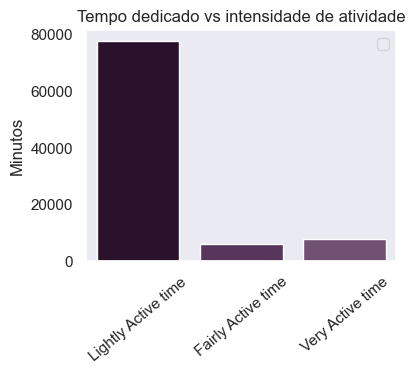

In [235]:
plt.figure(figsize=(4,3))
sns.barplot(data=df_active_min_sum, x='Active type', y= 'Minutes', hue='Active type')
plt.title('Tempo dedicado vs intensidade de atividade')
plt.xlabel('')
plt.legend('')
plt.xticks(rotation=40)
plt.ylabel('Minutos')
plt.grid(False)
plt.show()

### Análise de tipo de exercício (distância)

In [236]:
fairly_active_distance_per_id = d_activity.groupby('Id')['ModeratelyActiveDistance'].aggregate('sum')
very_active_distance_per_id = d_activity.groupby('Id')['VeryActiveDistance'].aggregate('sum')
lightly_active_distance_per_id = d_activity.groupby('Id')['LightActiveDistance'].aggregate('sum')

fairly_active_distance_sum = fairly_active_distance_per_id.sum()
very_active_distance_sum = very_active_distance_per_id.sum()
lightly_active_distance_sum = lightly_active_distance_per_id.sum()

In [237]:
active_distance_sum = pd.Series({'Lightly Active distance': lightly_active_distance_sum,'Fairly Active distance': fairly_active_distance_sum, 'Very Active distance': very_active_distance_sum })
active_distance_sum = active_distance_sum.reset_index()
active_distance_sum.columns = ['Active type', 'Distance']
active_distance_sum = active_distance_sum.sort_values(by='Distance', ascending=False)

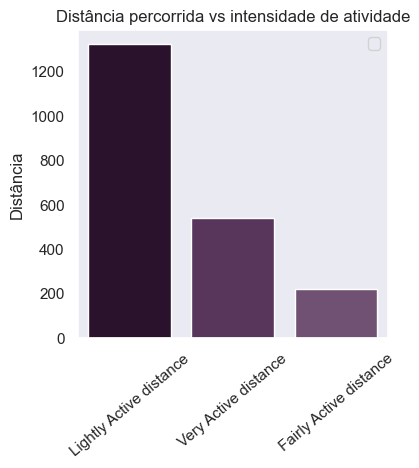

In [238]:
plt.figure(figsize=(4,4))
sns.barplot(data=active_distance_sum, x='Active type', y= 'Distance', hue='Active type')
plt.title('Distância percorrida vs intensidade de atividade')
plt.xlabel('')
plt.legend('')
plt.xticks(rotation=40)
plt.ylabel('Distância')
plt.grid(False)
plt.show()

### Checagem de timeframe dos dados e presença dos ids ao longo do tempo

In [ ]:
pd.pivot_table(d_activity, index='ActivityDate', values= 'Id', aggfunc='count').sort_values(by='ActivityDate', ascending= True)
# primeiras duas semanas dos dados só tem 2 usuários ativos, outros usuários se tornam ativos ao longo dos dias restantes
# 15 usos do fitbit por id deve levar em conta essa distribuição
# primeiro dia do dataframe: 12 de março . último dia do data frame: 12 de abril


### Dias com e sem uso de fitbit (assumindo que dias sem total steps são dias em que a pessoa não usou o fitbit, nõa que ela não se mexeu)

In [240]:

null_days = d_activity.loc[d_activity['TotalSteps']==0, 'ActivityDate'].value_counts().sum() #61
active_days= d_activity.loc[d_activity['TotalSteps']> 0, 'ActivityDate'].value_counts().sum() #396

active_null_distr = pd.Series({'Nulas' : null_days, 'Com atividade' : active_days})
active_null_distr = active_null_distr.reset_index()
active_null_distr.columns = ['Entradas', 'Contagem']

In [241]:
active_null_distr

,Entradas,Contagem
0,Nulas,61
1,Com atividade,396


In [242]:
active_distr = pd.DataFrame([null_days, active_days])

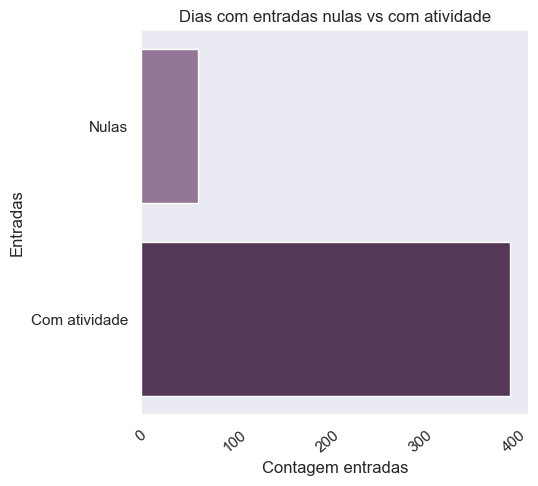

In [243]:
plt.figure(figsize=(5,5))
sns.barplot(data=active_null_distr, x= 'Contagem', y= 'Entradas', hue= 'Entradas', palette=[ "#97709B","#59315E"])
plt.title('Dias com entradas nulas vs com atividade')
plt.xlabel('Contagem entradas')
plt.xticks(rotation=40)
plt.grid(False)
plt.show()

In [244]:
weightlog['BMI_describe'].value_counts(dropna=False)

BMI_describe
Não informado    24
Normal weight    18
Overweight       13
Obesity           2
Name: count, dtype: int64

In [ ]:
weight_distr= weightlog[['Id','BMI_describe']].drop_duplicates()
weight_distr

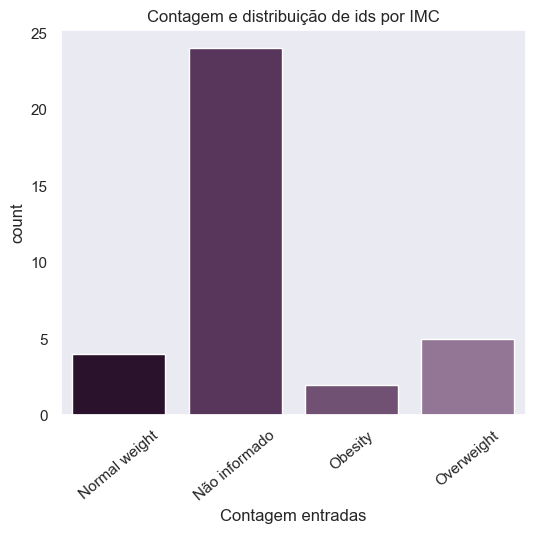

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(data=weight_distr, x='BMI_describe', hue='BMI_describe')
plt.title('Contagem e distribuição de ids por IMC')
plt.xticks(rotation=40)
plt.grid(False)
plt.show()